# 01 · EDA: the application table

**Goal:** understand the main table, check the known traps, and collect the numbers for the
*Data* section of the report. Run all cells from top to bottom (takes about 1–2 minutes).

At the end you write two things yourself: **Findings** (what you saw, with numbers) and
**Decisions** (cleaning rules for the feature code). The `facts` cell collects the key numbers for you.

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from creditrisk.config import get_path, set_seed

SEED = set_seed()
INTERIM, FIG = get_path("interim"), get_path("figures")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
facts = {}  # key numbers for the Findings, printed at the end


def save(fig, name):
    """Save a figure for the report."""
    fig.savefig(FIG / name, dpi=150, bbox_inches="tight")
    print(f"saved reports/figures/{name}")


app = pd.read_parquet(INTERIM / "application_train.parquet")
test = pd.read_parquet(INTERIM / "application_test.parquet")
print("train:", app.shape, "| test:", test.shape)
print(f"memory: {app.memory_usage(deep=True).sum() / 1e6:.0f} MB")

train: (307511, 122) | test: (48744, 121)
memory: 100 MB


## A. Target

TARGET
0    282686
1     24825
default rate: 8.07%
always predicting 'no default' already gives 91.9% accuracy
-> accuracy is useless here; use ROC-AUC and PR-AUC instead
saved reports/figures/fig01_target_balance.png


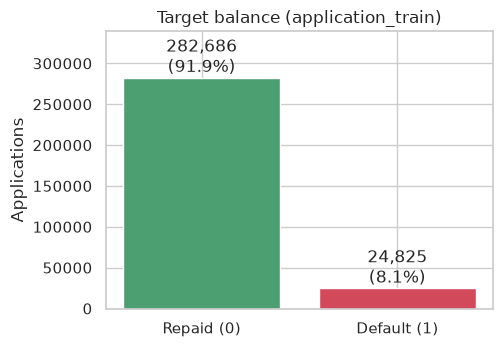

In [2]:
counts = app["TARGET"].value_counts().sort_index()
rate = app["TARGET"].mean()
facts["n_rows"] = len(app)
facts["n_defaults"] = int(counts[1])
facts["default_rate_%"] = round(100 * rate, 2)
facts["accuracy_if_always_no_default_%"] = round(100 * (1 - rate), 2)
print(counts.to_string())
print(f"default rate: {rate:.2%}")
print(f"always predicting 'no default' already gives {1 - rate:.1%} accuracy")
print("-> accuracy is useless here; use ROC-AUC and PR-AUC instead")

fig, ax = plt.subplots(figsize=(5, 3.6))
ax.bar(["Repaid (0)", "Default (1)"], counts.values, color=["#4C9F70", "#D1495B"])
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}\n({v / counts.sum():.1%})", ha="center", va="bottom")
ax.set_ylim(0, counts.max() * 1.2)
ax.set(title="Target balance (application_train)", ylabel="Applications")
save(fig, "fig01_target_balance.png")

## B. Missing values

67 of 122 columns have missing values; 41 are more than 50% missing


,missing %
COMMONAREA_AVG,69.9
COMMONAREA_MODE,69.9
COMMONAREA_MEDI,69.9
NONLIVINGAPARTMENTS_MEDI,69.4
NONLIVINGAPARTMENTS_MODE,69.4
NONLIVINGAPARTMENTS_AVG,69.4
FONDKAPREMONT_MODE,68.4
LIVINGAPARTMENTS_AVG,68.4
LIVINGAPARTMENTS_MEDI,68.4
LIVINGAPARTMENTS_MODE,68.4


saved reports/figures/fig02_missing.png


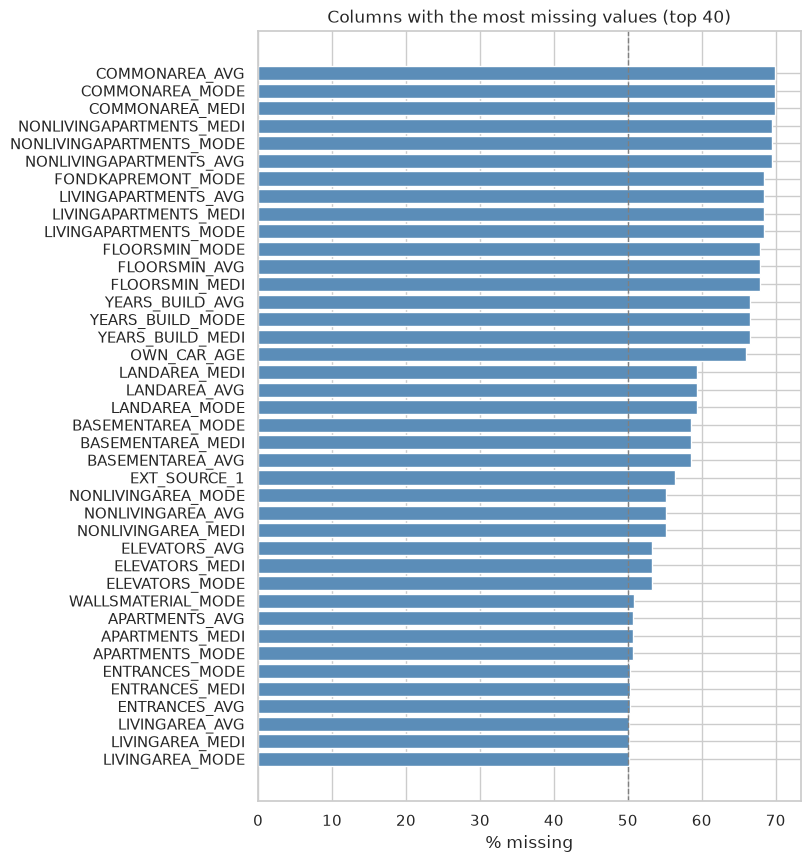

In [3]:
missing = app.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]
facts["cols_with_missing"] = int(len(missing))
facts["cols_over_50pct_missing"] = int((missing > 0.5).sum())
print(f"{len(missing)} of {app.shape[1]} columns have missing values; "
      f"{(missing > 0.5).sum()} are more than 50% missing")
display((100 * missing.head(15)).round(1).rename("missing %").to_frame())

top = missing.head(40)
fig, ax = plt.subplots(figsize=(7, max(3, 0.25 * len(top))))
ax.barh(top.index[::-1], 100 * top.values[::-1], color="#5B8DB8")
ax.axvline(50, color="grey", ls="--", lw=1)
ax.set(title="Columns with the most missing values (top 40)", xlabel="% missing")
save(fig, "fig02_missing.png")

Does *being missing* tell us something about default? If the two rates differ, keep a missing-flag feature.

In [4]:
rows = []
for col in ["EXT_SOURCE_1", "EXT_SOURCE_3", "OWN_CAR_AGE", "OCCUPATION_TYPE"]:
    is_missing = app[col].isna()
    rows.append({
        "column": col,
        "% missing": round(100 * is_missing.mean(), 1),
        "default % when missing": round(100 * app.loc[is_missing, "TARGET"].mean(), 2),
        "default % when present": round(100 * app.loc[~is_missing, "TARGET"].mean(), 2),
    })
missing_vs_target = pd.DataFrame(rows)
display(missing_vs_target)

,column,% missing,default % when missing,default % when present
0,EXT_SOURCE_1,56.4,8.52,7.50
1,EXT_SOURCE_3,19.8,9.31,7.77
2,OWN_CAR_AGE,66.0,8.50,7.24
3,OCCUPATION_TYPE,31.3,6.51,8.79


## C. Known traps

In [5]:
anom = app["DAYS_EMPLOYED"] == 365243
facts["days_employed_365243_rows"] = int(anom.sum())
facts["days_employed_365243_share_%"] = round(100 * anom.mean(), 1)
facts["default_%_in_365243_group"] = round(100 * app.loc[anom, "TARGET"].mean(), 2)
facts["default_%_everyone_else"] = round(100 * app.loc[~anom, "TARGET"].mean(), 2)
print(f"DAYS_EMPLOYED == 365243: {anom.sum():,} rows ({anom.mean():.1%})")
print(f"default rate: {app.loc[anom, 'TARGET'].mean():.2%} in this group "
      f"vs {app.loc[~anom, 'TARGET'].mean():.2%} for everyone else")
print("\nNAME_INCOME_TYPE inside this group:")
print(app.loc[anom, "NAME_INCOME_TYPE"].value_counts().loc[lambda s: s > 0].to_string())
xna_org = (app.loc[anom, "ORGANIZATION_TYPE"] == "XNA").mean()
facts["share_of_365243_group_with_org_XNA_%"] = round(100 * xna_org, 1)
print(f"\nShare of this group with ORGANIZATION_TYPE == 'XNA': {xna_org:.1%}")

DAYS_EMPLOYED == 365243: 55,374 rows (18.0%)
default rate: 5.40% in this group vs 8.66% for everyone else

NAME_INCOME_TYPE inside this group:
NAME_INCOME_TYPE
Pensioner     55352
Unemployed       22

Share of this group with ORGANIZATION_TYPE == 'XNA': 100.0%


CODE_GENDER == 'XNA': 4 rows

AMT_INCOME_TOTAL percentiles:
0.01         45,000
0.25        112,500
0.50        147,150
0.75        202,500
0.99        472,500
1.00    117,000,000
saved reports/figures/fig03_income_log.png


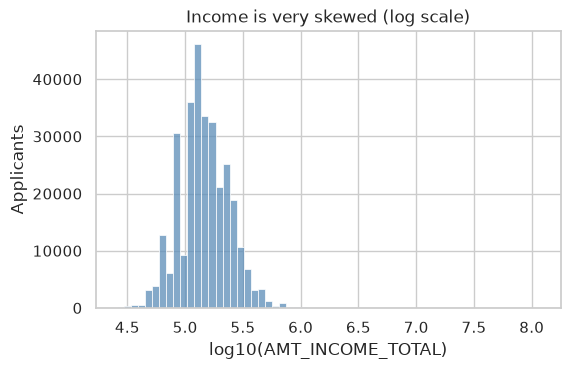

In [6]:
xna = int((app["CODE_GENDER"] == "XNA").sum())
facts["gender_XNA_rows"] = xna
print(f"CODE_GENDER == 'XNA': {xna} rows")

income = app["AMT_INCOME_TOTAL"]
facts["income_median"] = float(income.median())
facts["income_max"] = float(income.max())
print("\nAMT_INCOME_TOTAL percentiles:")
print(income.quantile([0.01, 0.25, 0.5, 0.75, 0.99, 1.0]).map("{:,.0f}".format).to_string())

fig, ax = plt.subplots(figsize=(6, 3.6))
sns.histplot(np.log10(income), bins=60, ax=ax, color="#5B8DB8")
ax.set(title="Income is very skewed (log scale)",
       xlabel="log10(AMT_INCOME_TOTAL)", ylabel="Applicants")
save(fig, "fig03_income_log.png")

Near-constant columns (one value in more than 99% of rows) carry almost no information.

In [7]:
top_share = app.apply(lambda s: s.value_counts(normalize=True, dropna=False).iloc[0])
near_constant = top_share[top_share > 0.99].sort_values(ascending=False)
facts["near_constant_columns"] = list(near_constant.index)
print(f"{len(near_constant)} near-constant columns:")
display((100 * near_constant).round(3).rename("% rows with the top value").to_frame())

18 near-constant columns:


,% rows with the top value
FLAG_MOBIL,100.000
FLAG_DOCUMENT_12,99.999
FLAG_DOCUMENT_10,99.998
FLAG_DOCUMENT_2,99.996
FLAG_DOCUMENT_4,99.992
FLAG_DOCUMENT_7,99.981
FLAG_DOCUMENT_17,99.973
FLAG_DOCUMENT_21,99.967
FLAG_DOCUMENT_20,99.949
FLAG_DOCUMENT_19,99.940


## D. What relates to default

saved reports/figures/fig04_target_correlations.png
Careful: DAYS_* columns are negative numbers. A positive correlation for DAYS_BIRTH means YOUNGER people default more.


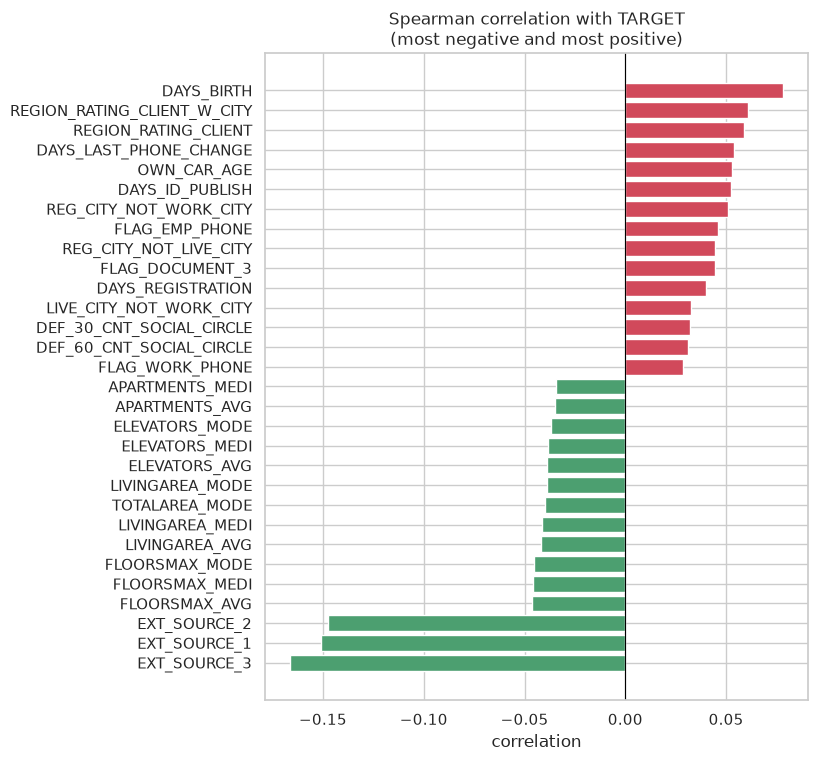

In [8]:
num_cols = app.select_dtypes("number").columns.drop(["SK_ID_CURR", "TARGET"])
corr = app[num_cols].corrwith(app["TARGET"], method="spearman").dropna().sort_values()
show = pd.concat([corr.head(15), corr.tail(15)]).drop_duplicates()
facts["most_negative_corr"] = corr.head(5).round(3).to_dict()
facts["most_positive_corr"] = corr.tail(5).round(3).to_dict()

fig, ax = plt.subplots(figsize=(7, max(3, 0.28 * len(show))))
ax.barh(show.index, show.values, color=np.where(show.values > 0, "#D1495B", "#4C9F70"))
ax.axvline(0, color="black", lw=0.8)
ax.set(title="Spearman correlation with TARGET\n(most negative and most positive)",
       xlabel="correlation")
save(fig, "fig04_target_correlations.png")
print("Careful: DAYS_* columns are negative numbers. A positive correlation for DAYS_BIRTH "
      "means YOUNGER people default more.")

saved reports/figures/fig05_ext_sources.png
saved reports/figures/fig06_age.png


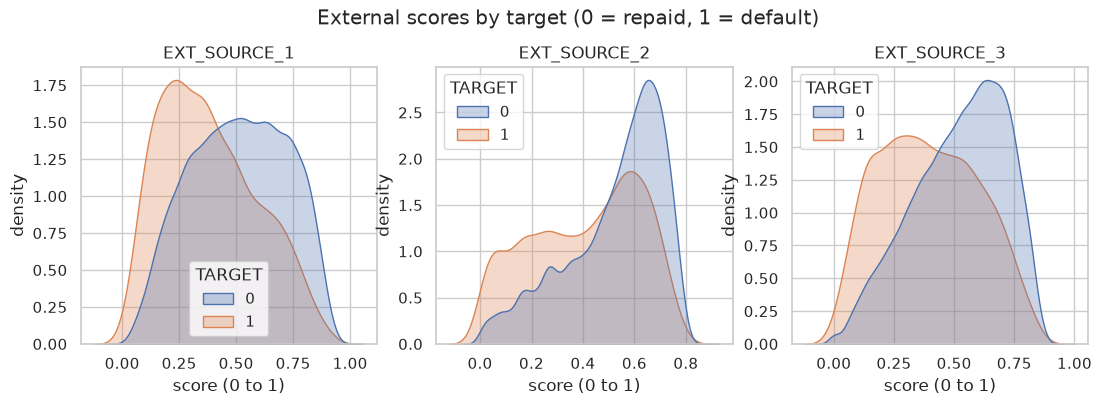

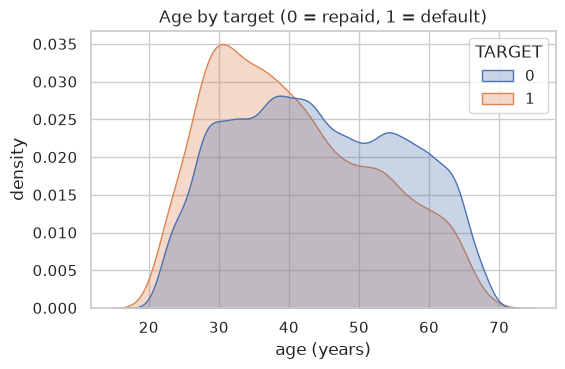

In [9]:
sample = app.sample(n=min(60_000, len(app)), random_state=SEED)
sample = sample.assign(AGE_YEARS=-sample["DAYS_BIRTH"] / 365.25)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, col in zip(axes, ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"], strict=True):
    sns.kdeplot(data=sample, x=col, hue="TARGET", common_norm=False, fill=True, alpha=0.3, ax=ax)
    ax.set(title=col, xlabel="score (0 to 1)", ylabel="density")
fig.suptitle("External scores by target (0 = repaid, 1 = default)", y=1.04)
save(fig, "fig05_ext_sources.png")

fig, ax = plt.subplots(figsize=(6, 3.6))
sns.kdeplot(data=sample, x="AGE_YEARS", hue="TARGET", common_norm=False,
            fill=True, alpha=0.3, ax=ax)
ax.set(title="Age by target (0 = repaid, 1 = default)", xlabel="age (years)", ylabel="density")
save(fig, "fig06_age.png")

Default rate per category. The red dashed line is the overall default rate and `n` is the group size. Groups with fewer than 100 rows are hidden (their rates are unreliable) and listed above the plot.

CODE_GENDER: hiding tiny groups (n < 100): {'XNA': 4}
NAME_INCOME_TYPE: hiding tiny groups (n < 100): {'Businessman': 10, 'Maternity leave': 5, 'Student': 18, 'Unemployed': 22}
NAME_FAMILY_STATUS: hiding tiny groups (n < 100): {'Unknown': 2}
ORGANIZATION_TYPE: hiding tiny groups (n < 100): {'Industry: type 13': 67, 'Industry: type 8': 24, 'Religion': 85, 'Trade: type 4': 64, 'Trade: type 5': 49}
saved reports/figures/fig07_default_by_category.png


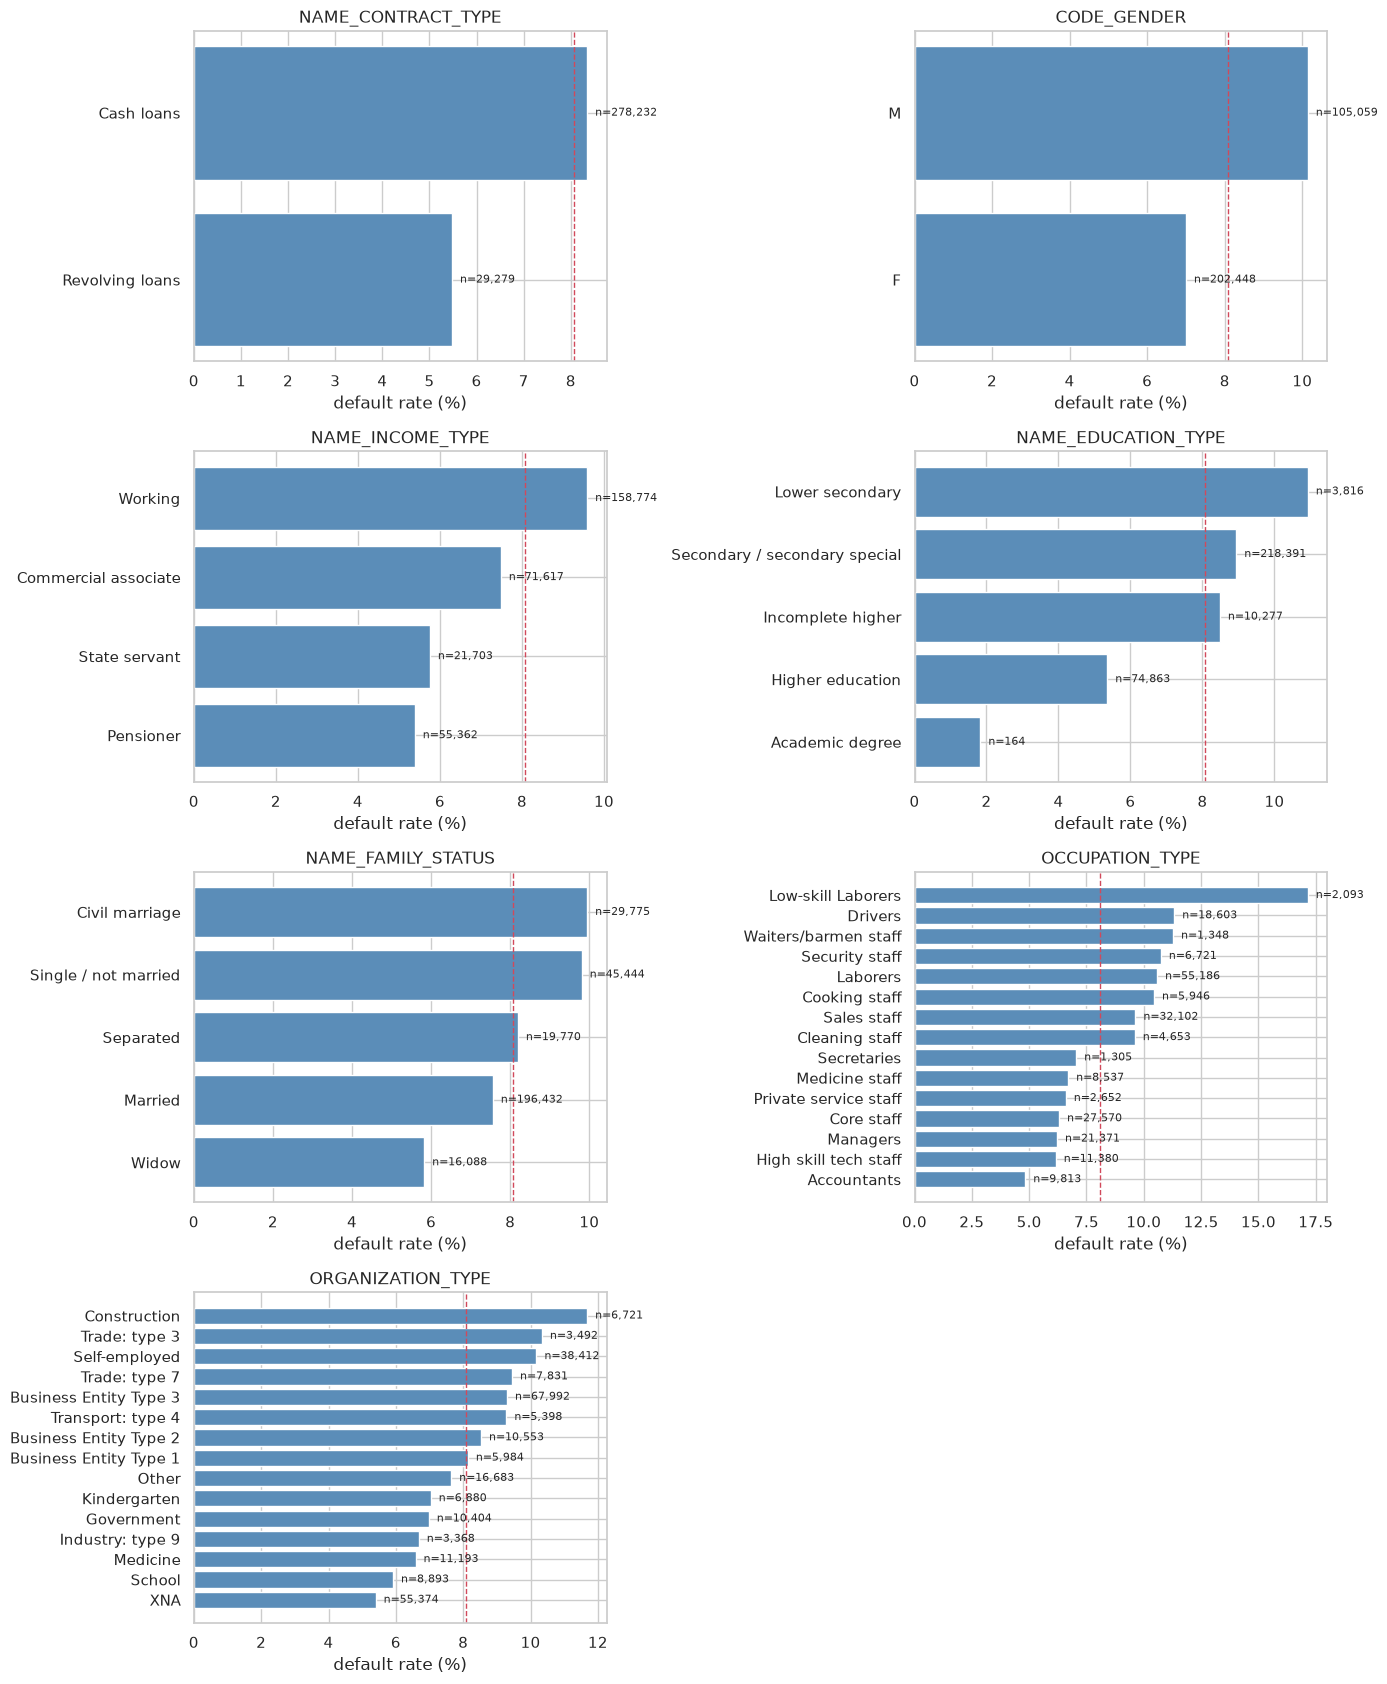

In [10]:
def default_rate_by(col, top=15, min_count=100):
    g = app.groupby(col, observed=True)["TARGET"].agg(default_rate="mean", count="size")
    small = g[g["count"] < min_count]
    if len(small):
        hidden = {str(k): int(v) for k, v in small["count"].items()}
        print(f"{col}: hiding tiny groups (n < {min_count}): {hidden}")
    g = g[g["count"] >= min_count].sort_values("count", ascending=False).head(top)
    return g.sort_values("default_rate")


cat_cols = ["NAME_CONTRACT_TYPE", "CODE_GENDER", "NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE",
            "NAME_FAMILY_STATUS", "OCCUPATION_TYPE", "ORGANIZATION_TYPE"]
fig, axes = plt.subplots(4, 2, figsize=(14, 17))
for ax, col in zip(axes.flat, cat_cols, strict=False):  # 8 boxes, 7 plots
    g = default_rate_by(col)
    ax.barh(g.index.astype(str), 100 * g["default_rate"], color="#5B8DB8")
    for y, (r, cnt) in enumerate(zip(g["default_rate"], g["count"], strict=True)):
        ax.text(100 * r, y, f"  n={cnt:,}", va="center", fontsize=8)
    ax.axvline(100 * app["TARGET"].mean(), color="#D1495B", ls="--", lw=1)
    ax.set(title=col, xlabel="default rate (%)")
axes.flat[-1].axis("off")
fig.tight_layout()
save(fig, "fig07_default_by_category.png")

## E. Fairness preview
The gap between groups here is the starting point of the fairness section later.

,default_rate,count
CODE_GENDER,,
F,0.069993,202448
M,0.101419,105059


,default_rate,count
DAYS_BIRTH,,
<30,0.114438,45186
30-45,0.090022,123737
45-60,0.065633,103287
60+,0.049177,35301


saved reports/figures/fig08_default_by_gender_age.png


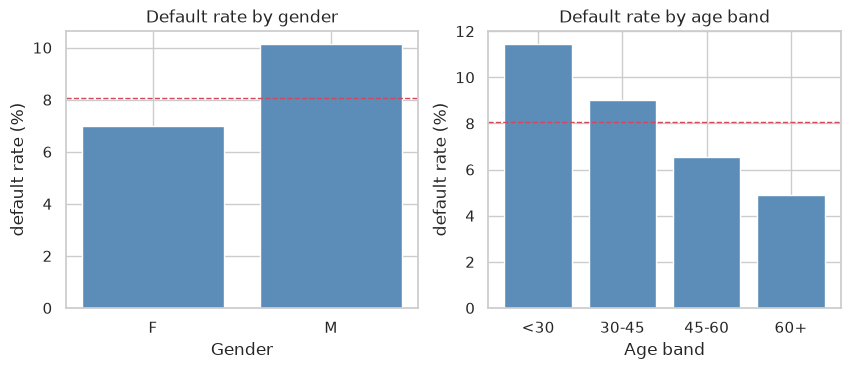

In [11]:
age_band = pd.cut(-app["DAYS_BIRTH"] / 365.25, bins=[0, 30, 45, 60, 120],
                  labels=["<30", "30-45", "45-60", "60+"], right=False)
by_gender = (
    app[app["CODE_GENDER"] != "XNA"]
    .groupby("CODE_GENDER", observed=True)["TARGET"]
    .agg(default_rate="mean", count="size")
)
by_age = app.groupby(age_band, observed=True)["TARGET"].agg(default_rate="mean", count="size")
facts["default_%_by_gender"] = (100 * by_gender["default_rate"]).round(2).to_dict()
facts["default_%_by_age_band"] = (100 * by_age["default_rate"]).round(2).to_dict()
display(by_gender, by_age)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, (title, g) in zip(axes, [("Gender", by_gender), ("Age band", by_age)], strict=True):
    ax.bar(g.index.astype(str), 100 * g["default_rate"], color="#5B8DB8")
    ax.axhline(100 * app["TARGET"].mean(), color="#D1495B", ls="--", lw=1)
    ax.set(title=f"Default rate by {title.lower()}", xlabel=title, ylabel="default rate (%)")
save(fig, "fig08_default_by_gender_age.png")

## F. Features that copy each other
Pairs with |correlation| > 0.9 (computed on a 60k-row sample to keep it fast). This list is the reason to use PCA on the building columns.

In [12]:
c = sample[num_cols].corr().abs()
upper = c.where(np.triu(np.ones(c.shape, dtype=bool), k=1))
pairs = upper.stack().loc[lambda s: s > 0.9].sort_values(ascending=False)
facts["pairs_with_abs_corr_over_0.9"] = int(len(pairs))
print(f"{len(pairs)} pairs of numeric columns with |correlation| > 0.9")
display(pairs.rename("abs corr").round(3).to_frame().head(30))

64 pairs of numeric columns with |correlation| > 0.9


,,abs corr
DAYS_EMPLOYED,FLAG_EMP_PHONE,1.000
OBS_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,0.998
LIVINGAPARTMENTS_AVG,LIVINGAPARTMENTS_MEDI,0.998
NONLIVINGAPARTMENTS_AVG,NONLIVINGAPARTMENTS_MEDI,0.998
COMMONAREA_AVG,COMMONAREA_MEDI,0.998
YEARS_BUILD_AVG,YEARS_BUILD_MEDI,0.998
APARTMENTS_AVG,APARTMENTS_MEDI,0.998
ENTRANCES_AVG,ENTRANCES_MEDI,0.997
FLOORSMIN_AVG,FLOORSMIN_MEDI,0.997
LIVINGAREA_AVG,LIVINGAREA_MEDI,0.997


## G. Train vs test
If the test file looks different from train, that is an early hint for the drift section.

,train %,test %
NAME_CONTRACT_TYPE,,
Cash loans,90.48,99.1
Revolving loans,9.52,0.9


,train mean,test mean
EXT_SOURCE_2,0.514,0.5180
EXT_SOURCE_3,0.511,0.5000
AMT_CREDIT,599026.000,516740.4375


saved reports/figures/fig09_train_vs_test.png


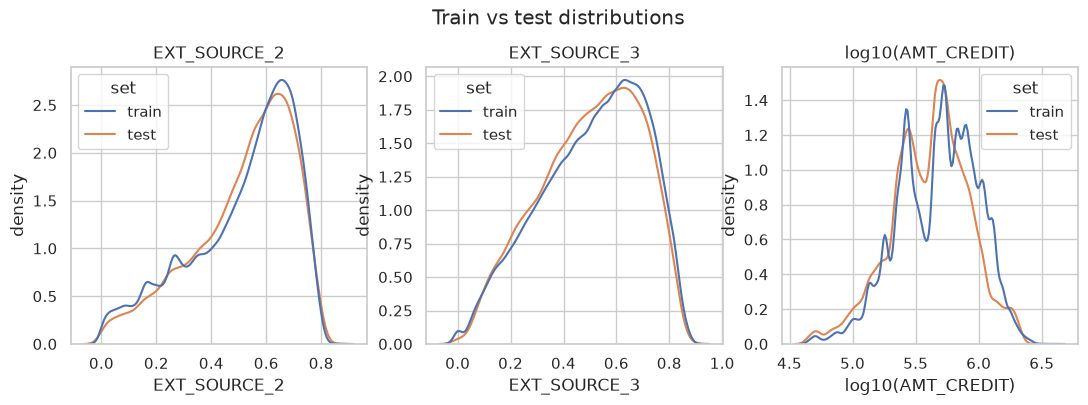

In [13]:
def shares(s):
    v = s.value_counts(normalize=True)
    v.index = v.index.astype(str)
    return 100 * v


contract_share = pd.DataFrame({"train %": shares(app["NAME_CONTRACT_TYPE"]),
                               "test %": shares(test["NAME_CONTRACT_TYPE"])}).round(2)
facts["contract_type_%_train_vs_test"] = contract_share.to_dict()
display(contract_share)

cols = ["EXT_SOURCE_2", "EXT_SOURCE_3", "AMT_CREDIT"]
display(pd.DataFrame({"train mean": app[cols].mean(), "test mean": test[cols].mean()}).round(3))

both = pd.concat([app[cols].assign(set="train"), test[cols].assign(set="test")], ignore_index=True)
both["log10(AMT_CREDIT)"] = np.log10(both["AMT_CREDIT"])
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, col in zip(axes, ["EXT_SOURCE_2", "EXT_SOURCE_3", "log10(AMT_CREDIT)"], strict=True):
    sns.kdeplot(data=both, x=col, hue="set", common_norm=False, ax=ax)
    ax.set(title=col, ylabel="density")
fig.suptitle("Train vs test distributions", y=1.04)
save(fig, "fig09_train_vs_test.png")

## Key facts
Copy these numbers into your Findings below.

In [14]:
for key, value in facts.items():
    print(f"{key:<40} {value}")

n_rows                                   307511
n_defaults                               24825
default_rate_%                           8.07
accuracy_if_always_no_default_%          91.93
cols_with_missing                        67
cols_over_50pct_missing                  41
days_employed_365243_rows                55374
days_employed_365243_share_%             18.0
default_%_in_365243_group                5.4
default_%_everyone_else                  8.66
share_of_365243_group_with_org_XNA_%     100.0
gender_XNA_rows                          4
income_median                            147150.0
income_max                               117000000.0
near_constant_columns                    ['FLAG_MOBIL', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_21', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_15', 'FLAG_CONT_MOBILE', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_

## Findings

- **Target:** 24,825 of 307,511 applicants defaulted (8.07%). Always predicting "no default" already gives 91.93% accuracy, so we use ROC-AUC, PR-AUC and KS instead of accuracy.
- **Missing values:** 67 of 122 columns have missing values; 41 are more than 50% missing (mostly building information).
- **Missing as a signal:** when EXT_SOURCE_1 is missing the default rate is __% vs __% when present, so missing flags are useful features.
- **The 365243 code:** 55,374 rows (18.0%) have DAYS_EMPLOYED = 365243, all with ORGANIZATION_TYPE = "XNA". Their default rate is 5.40% vs 8.66% for everyone else, so the flag itself carries information.
- **Data errors:** 4 rows have CODE_GENDER = "XNA". Income is very skewed: the median is 147,150 but one applicant reports 117,000,000.
- **Near-constant columns:** 18 columns have one value in more than 99% of rows (FLAG_MOBIL, FLAG_CONT_MOBILE and 16 FLAG_DOCUMENT_* columns).
- **Strongest single features:** the three external scores (Spearman with TARGET: EXT_SOURCE_3 −0.166, EXT_SOURCE_1 −0.151, EXT_SOURCE_2 −0.147). A higher score means lower risk.
- **Age:** younger applicants default much more: 11.44% under 30 vs 4.92% at 60+ (2.3 times higher).
- **Region:** a worse region rating goes with more defaults (REGION_RATING_CLIENT_W_CITY, 0.061).
- **Gender:** men default at 10.14% vs women at 7.00% (1.45 times higher). Because the base rates differ, a model cannot be perfectly calibrated for both groups and also have equal error rates for both; this matters in the fairness section.
- **Redundant features:** 64 pairs of numeric columns have |correlation| > 0.9, mostly the building _AVG / _MODE / _MEDI triples.
- **Train vs test:** the Kaggle test file has far fewer revolving loans (0.9% vs 9.52%); PSI for contract type is 0.21, a moderate shift.

## Decisions

- DAYS_EMPLOYED = 365243 → NaN, plus a flag column DAYS_EMPLOYED_ANOM.
- Drop the 4 rows with CODE_GENDER = "XNA".
- First add DOC_COUNT (number of documents provided = sum of all FLAG_DOCUMENT_*), then drop the 18 near-constant columns.
- Income: use log(AMT_INCOME_TOTAL), capped at the 99.9th percentile of the training data.
- Building columns: compress with PCA inside the model pipeline (fit on training folds only).
- Keep NaN for tree models; for linear models, KNN, SVM and the MLP use median imputation plus missing flags.
- Evaluate on our own stratified split of application_train. The Kaggle test file is used only as unlabeled data and as a drift example.